# 00 · Dataset imbalance & the exact PR-AUC baseline
The PR-AUC of a random classifier equals the **positive prevalence of the set it is evaluated on**. Our models are scored on the **test** set, so the baseline is the **test** prevalence — *not* the training prior. We verify this against the Session-1 Dummy row.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().resolve().parents[1]  # notebooks/ -> 02_cv_strategies/
sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings('ignore')
import json, numpy as np, pandas as pd
from IPython.display import HTML, display
from cv_strategies import config as C, evaluation_ext as E, report as R
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('session folder:', ROOT)

project root: D:\_fcall\UNIFEI\tcc\hpc_workload


In [2]:
imb = json.loads(C.IMBALANCE_JSON.read_text())
print('PR-AUC baseline (test prevalence):', round(imb['pr_auc_baseline'],4))
print('train prior               :', round(imb['train_prior'],4))
print('scale_pos_weight (train)   :', round(imb['scale_pos_weight_train'],4))
print('reconciliation             :', imb.get('reconciliation'))

PR-AUC baseline (test prevalence): 0.0403
train prior               : 0.032
scale_pos_weight (train)   : 30.2601
reconciliation             : OK: baseline==Dummy.pr_auc and train_prior==Dummy.mean_proba


### Per-state positives (test)

In [3]:
ps = imb['test']['per_state']
pd.DataFrame([{'state':k, **v} for k,v in ps.items()])

,state,windows,positives,pos_frac_within_state,share_of_all_positives
0,COMPLETED,926422,0,0.0000,0.0000
1,TIMEOUT,408660,39857,0.0975,0.7013
2,FAILED,51962,12862,0.2475,0.2263
3,OOM,1606,1592,0.9913,0.0280
4,NODE_FAIL,23159,2520,0.1088,0.0443


### Session-1 models against the correct baseline


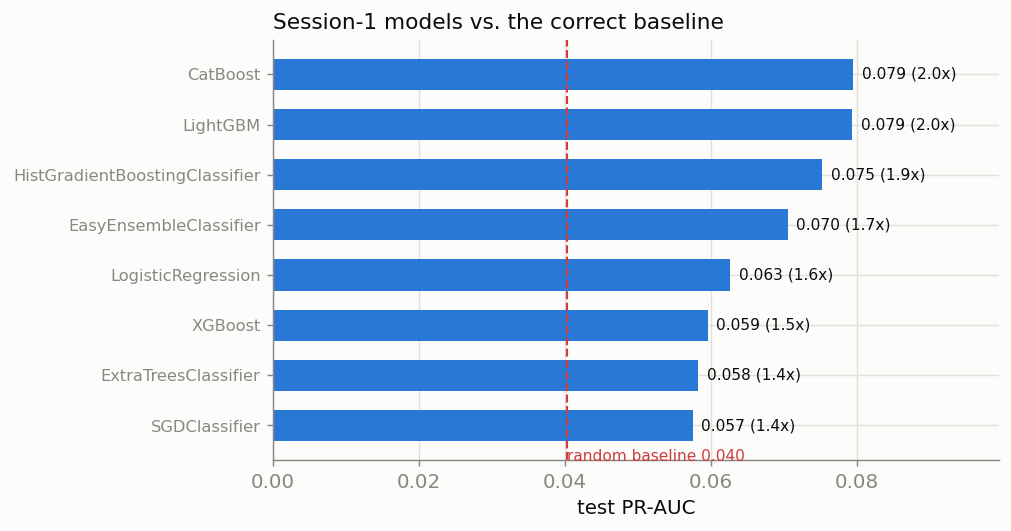

In [4]:
display(HTML(f'<img src="{R.fig_lift(pd.DataFrame(imb['session1_lift'])[['model','pr_auc']][:8], imb['pr_auc_baseline'])}">'))

**Takeaway.** Best model ≈ **1.97×** the correct baseline (0.0403), not the ~2.5× the train prior (0.0320) would suggest. TIMEOUT supplies ~70% of positives; OOM is tiny but almost entirely positive.